
<br>
<font face="Times New Roman">
<div dir=ltr align=center>
<font color=0F5298 size=7>
Digital Image Processing <br>
<font color=2565AE size=5>
Department Of Mathematical Sciences <br>
Spring 2025<br>
<font color=3C99D size=5>
Assignment 3 <br>
</div>


---



### Full Name : Amir Malekhosseini
### Student Number : 401100528
___

In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Helper Functions for DCT, SSIM, and Image Operations

In [ ]:
_DCT_MATRIX_N8 = None
_IDCT_MATRIX_N8 = None

def _init_dct_matrices():
    global _DCT_MATRIX_N8, _IDCT_MATRIX_N8
    if _DCT_MATRIX_N8 is None:
        N_mat = 8
        T_mat = np.zeros((N_mat, N_mat), dtype=float)
        for k_mat in range(N_mat):
            for n_mat in range(N_mat):
                T_mat[k_mat, n_mat] = np.cos(np.pi * k_mat * (2 * n_mat + 1) / (2 * N_mat))
            if k_mat == 0:
                T_mat[k_mat, :] *= np.sqrt(1/N_mat)
            else:
                T_mat[k_mat, :] *= np.sqrt(2/N_mat)
        _DCT_MATRIX_N8 = T_mat
        _IDCT_MATRIX_N8 = T_mat.T 

# --- SSIM Helper Functions ---
def convolve_1d_uniform_reflect(vector, F_size):
    if F_size <= 0:
        raise ValueError("Filter size must be positive")
    if F_size % 2 == 0:
        F_size +=1 

    pad_width = F_size // 2
    vec_padded = np.pad(vector, pad_width, mode='reflect')
    out = np.zeros_like(vector, dtype=float)
    for i in range(len(vector)):
        out[i] = np.mean(vec_padded[i : i+F_size])
    return out

def uniform_filter_2d_separable(image, F_size):
    img_filtered_rows = np.zeros_like(image, dtype=float)
    for r in range(image.shape[0]):
        img_filtered_rows[r, :] = convolve_1d_uniform_reflect(image[r, :], F_size)
    
    img_filtered_final = np.zeros_like(image, dtype=float)
    for c in range(image.shape[1]):
        img_filtered_final[:, c] = convolve_1d_uniform_reflect(img_filtered_rows[:, c], F_size)
        
    return img_filtered_final

def my_structural_similarity_windowed(img1_in, img2_in, data_range, win_size=7):
    if img1_in.shape != img2_in.shape:
        raise ValueError('Input images must have the same dimensions.')

    img1 = img1_in.astype(float)
    img2 = img2_in.astype(float)

    K1 = 0.01
    K2 = 0.03
    L = float(data_range)
    C1 = (K1 * L)**2
    C2 = (K2 * L)**2
    
    mu1 = uniform_filter_2d_separable(img1, win_size)
    mu2 = uniform_filter_2d_separable(img2, win_size)

    mu1_sq = mu1**2
    mu2_sq = mu2**2
    mu1_mu2 = mu1 * mu2

    sigma1_sq = uniform_filter_2d_separable(img1**2, win_size) - mu1_sq
    sigma2_sq = uniform_filter_2d_separable(img2**2, win_size) - mu2_sq
    sigma12 = uniform_filter_2d_separable(img1 * img2, win_size) - mu1_mu2
    
    sigma1_sq = np.maximum(0, sigma1_sq)
    sigma2_sq = np.maximum(0, sigma2_sq)

    numerator = (2 * mu1_mu2 + C1) * (2 * sigma12 + C2)
    denominator = (mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2)
    
    ssim_map = numerator / denominator
    

    return np.mean(ssim_map[np.isfinite(ssim_map)])

# --- Image Resizing Helper ---
def nn_resize(img, out_h, out_w):
    in_h, in_w = img.shape[:2] 
    is_color = img.ndim == 3
    num_channels = img.shape[2] if is_color else 1

    out_h = max(1, int(out_h))
    out_w = max(1, int(out_w))
    
    if is_color:
        resized_img = np.zeros((out_h, out_w, num_channels), dtype=img.dtype)
    else:
        resized_img = np.zeros((out_h, out_w), dtype=img.dtype)

    y_scale = (in_h -1) / max(1, (out_h - 1)) if out_h > 1 else 0
    x_scale = (in_w -1) / max(1, (out_w - 1)) if out_w > 1 else 0

    for i in range(out_h):
        for j in range(out_w):
            orig_i = int(round(i * y_scale))
            orig_j = int(round(j * x_scale))
            orig_i = min(orig_i, in_h - 1)
            orig_j = min(orig_j, in_w - 1)
            if is_color:
                resized_img[i, j, :] = img[orig_i, orig_j, :]
            else:
                resized_img[i, j] = img[orig_i, orig_j]
    return resized_img

## Step 1: Divide image into 8x8 blocks and apply DCT
## (use realimage.jpg)

In [ ]:
def apply_dct(image_array):
    _init_dct_matrices() 
    if image_array.dtype != np.float64 and image_array.dtype != np.float32:
        image = image_array.astype(float)
    else:
        image = image_array.copy()

    h, w = image.shape

    h_pad = (8 - h % 8) % 8
    w_pad = (8 - w % 8) % 8

    img_padded = np.pad(image, ((0, h_pad), (0, w_pad)), 'constant')

    padded_h, padded_w = img_padded.shape

    num_blocks_h = padded_h // 8
    num_blocks_w = padded_w // 8
    dct_blocks = np.zeros((num_blocks_h, num_blocks_w, 8, 8), dtype=float)

    for r_idx in range(num_blocks_h):
        for c_idx in range(num_blocks_w):
            block = img_padded[r_idx*8:(r_idx+1)*8, c_idx*8:(c_idx+1)*8]
            

            dct_blocks[r_idx, c_idx] = _DCT_MATRIX_N8 @ block @ _IDCT_MATRIX_N8

    return dct_blocks

## Step 2: Quantization


In [4]:
# Quantization matrix

Z = np.array([[16,11,10,16,24,40,51,61],
              [12,12,14,19,26,58,60,55],
              [14,13,16,24,40,57,69,56],
              [14,17,22,29,51,87,80,62],
              [18,22,37,56,68,109,103,77],
              [24,35,55,64,81,104,113,92],
              [49,64,78,87,103,121,120,101],
              [72,92,95,98,112,100,130,99]])

In [5]:
def quantize(dct_blocks):
    num_blocks_h, num_blocks_w, _, _ = dct_blocks.shape
    quantized_blocks = np.zeros_like(dct_blocks, dtype=float)

    for r_idx in range(num_blocks_h):
        for c_idx in range(num_blocks_w):
            block = dct_blocks[r_idx, c_idx]
            quantized_block = np.round(block / Z)
            quantized_blocks[r_idx, c_idx] = quantized_block

    return quantized_blocks.astype(int)

### Matrix to vector
Now you need to convert the matrix to an array like this:

`[-17, 0, -19, ..., 'EOB']`

In [6]:
def mat_2_vec(jpeg_matrix):  
    n = jpeg_matrix.shape[0]  
    result_list = []
    r, c = 0, 0  

    for _ in range(n*n):  
        result_list.append(jpeg_matrix[r, c])

        
        if (r + c) % 2 == 0: 
            if c == n - 1:   
                r += 1     
            elif r == 0:     
                c += 1    
            else:          
                r -= 1       
                c += 1   
        else:  
            if r == n - 1:  
                c += 1    
            elif c == 0:     
                r += 1      
            else:         
                r += 1       
                c -= 1       

    
    while len(result_list) > 0 and result_list[-1] == 0:
        result_list.pop()

    jpeg_vector = result_list  
    jpeg_vector.append('EOB')

    return jpeg_vector

## Step 3: Apply Inverse DCT for decompression

In [ ]:
def apply_idct(quantized_blocks):
    _init_dct_matrices() 
    num_blocks_h, num_blocks_w, _, _ = quantized_blocks.shape

    dequantized_blocks = np.zeros_like(quantized_blocks, dtype=float)
    for r_idx in range(num_blocks_h):
        for c_idx in range(num_blocks_w):
            block = quantized_blocks[r_idx, c_idx]  
            dequantized_block = block.astype(float) * Z
            dequantized_blocks[r_idx, c_idx] = dequantized_block

 
    reconstructed_image_blocks = np.zeros_like(dequantized_blocks, dtype=float)
    for r_idx in range(num_blocks_h):
        for c_idx in range(num_blocks_w):
            dequantized_block = dequantized_blocks[r_idx, c_idx]

            reconstructed_block = _IDCT_MATRIX_N8 @ dequantized_block @ _DCT_MATRIX_N8
            reconstructed_image_blocks[r_idx, c_idx] = reconstructed_block

    padded_h = num_blocks_h * 8
    padded_w = num_blocks_w * 8
    decompressed_image_padded = np.zeros((padded_h, padded_w), dtype=float)

    for r_idx in range(num_blocks_h):
        for c_idx in range(num_blocks_w):
            block = reconstructed_image_blocks[r_idx, c_idx]
            decompressed_image_padded[r_idx *
                                      8:(r_idx+1)*8, c_idx*8:(c_idx+1)*8] = block

    decompressed_image_clipped = np.clip(decompressed_image_padded, 0, 255)

    return decompressed_image_clipped.astype(np.uint8)

### Run


Step 1: Applying DCT...
Shape of DCT blocks: (64, 64, 8, 8)

Step 2: Quantizing DCT blocks...
Shape of Quantized blocks: (64, 64, 8, 8)

Calculating total compressed bits...
Total estimated compressed bits: 128458

Step 3: Applying Inverse DCT for decompression...
Shape of Decompressed (padded) image: (512, 512)
Shape of Decompressed (cropped to original) image: (512, 512)

Calculating quality metrics (MSE, PSNR, SSIM)...
Mean Squared Error (MSE): 17.02
Peak Signal-to-Noise Ratio (PSNR): 35.82 dB
Structural Similarity Index (SSIM): 0.9549

Calculating compression rate...
Original image size: 2097152 bits
Compressed image size (estimated): 128458 bits
Compression Ratio: 16.33 : 1

Displaying images...


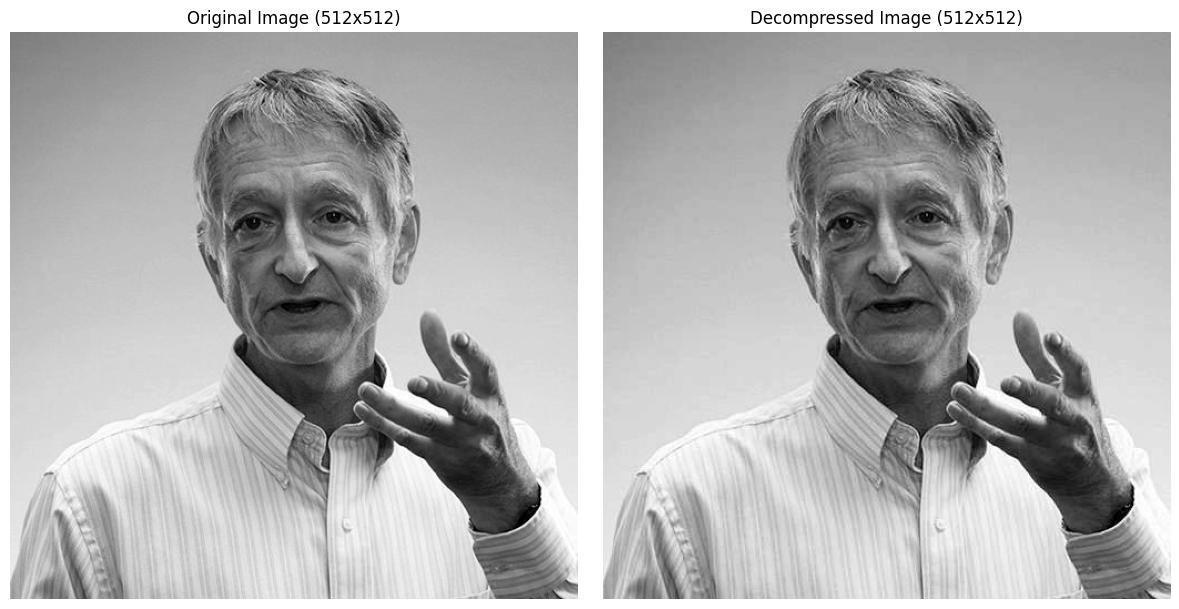

In [ ]:
def get_bits_for_value_simple(value):
    py_value = int(value)
    if py_value == 0:
        return 1  
    else:
        magnitude_bits = py_value.bit_length()
        sign_bit = 1  
        return magnitude_bits + sign_bit
    
IMAGE_PATH = "realimage.jpg"  
IS_DUMMY_IMAGE = False
TARGET_H, TARGET_W = 512, 512

try:
    img_array_loaded = plt.imread(IMAGE_PATH)

   
    if img_array_loaded.dtype == np.uint8:
        img_float_0_1 = img_array_loaded.astype(float) / 255.0
    elif img_array_loaded.dtype == np.uint16:
        img_float_0_1 = img_array_loaded.astype(float) / 65535.0
    elif img_array_loaded.dtype == float and img_array_loaded.max() > 1.0: 
        img_float_0_1 = img_array_loaded / 255.0
    else: 
        img_float_0_1 = img_array_loaded.copy()

    if img_float_0_1.ndim == 3:
        if img_float_0_1.shape[2] == 4: 
            img_float_0_1 = img_float_0_1[:, :, :3] 
        rgb_weights = np.array([0.299, 0.587, 0.114])
        img_gray_float_0_1 = np.dot(img_float_0_1, rgb_weights)
    else:
        img_gray_float_0_1 = img_float_0_1

    if img_gray_float_0_1.shape != (TARGET_H, TARGET_W):
        print(f"Original image shape: {img_gray_float_0_1.shape}. Resizing to ({TARGET_H},{TARGET_W}) using nearest neighbor.")
        img_gray_resized_0_1 = nn_resize(img_gray_float_0_1, TARGET_H, TARGET_W)
    else:
        img_gray_resized_0_1 = img_gray_float_0_1

    img_array_original = (img_gray_resized_0_1 * 255).clip(0, 255).astype(np.uint8)

except FileNotFoundError:
    print(f"Image file {IMAGE_PATH} not found. Using a dummy image.")
    img_array_original = np.random.randint(0, 256, size=(TARGET_H, TARGET_W), dtype=np.uint8)
    IS_DUMMY_IMAGE = True
except Exception as e:
    print(f"Error loading or processing image '{IMAGE_PATH}': {e}")
    print("Using a dummy image instead.")
    img_array_original = np.random.randint(0, 256, size=(TARGET_H, TARGET_W), dtype=np.uint8)
    IS_DUMMY_IMAGE = True

original_h, original_w = img_array_original.shape

_init_dct_matrices()

#  Apply DCT (Part الف)
print("\nStep 1: Applying DCT...")
dct_blocks = apply_dct(img_array_original)
print(f"Shape of DCT blocks: {dct_blocks.shape}")

#  Quantization (Part الف)
print("\nStep 2: Quantizing DCT blocks...")
quantized_blocks = quantize(dct_blocks)
print(f"Shape of Quantized blocks: {quantized_blocks.shape}")

print("\nCalculating total compressed bits...")
total_compressed_bits = 0
EOB_BITS = 4  

num_blocks_h, num_blocks_w, _, _ = quantized_blocks.shape
all_jpeg_vectors = []  

for r_idx in range(num_blocks_h):
    for c_idx in range(num_blocks_w):
        current_block_quantized = quantized_blocks[r_idx, c_idx]
        jpeg_vector = mat_2_vec(current_block_quantized)
        all_jpeg_vectors.append(jpeg_vector)

        for val in jpeg_vector:
            if val == 'EOB':
                total_compressed_bits += EOB_BITS
            else:  
                total_compressed_bits += get_bits_for_value_simple(val)
print(f"Total estimated compressed bits: {total_compressed_bits}")

# Apply Inverse DCT for decompression (Part ب)
print("\nStep 3: Applying Inverse DCT for decompression...")
decompressed_image_padded = apply_idct(quantized_blocks)
print(f"Shape of Decompressed (padded) image: {decompressed_image_padded.shape}")

decompressed_image = decompressed_image_padded[:original_h, :original_w]
print(f"Shape of Decompressed (cropped to original) image: {decompressed_image.shape}")

# Calculate Metrics (Part ج) 
print("\nCalculating quality metrics (MSE, PSNR, SSIM)...")

img_array_original_float = img_array_original.astype(float)
decompressed_image_float = decompressed_image.astype(float)

mse = np.mean((img_array_original_float - decompressed_image_float) ** 2)
if mse == 0:
    psnr = float('inf')
else:
    max_pixel_val = 255.0
    psnr = 20 * np.log10(max_pixel_val / np.sqrt(mse))

ssim_data_range = 255.0 
ssim_val = my_structural_similarity_windowed(img_array_original_float, decompressed_image_float,
                                           data_range=ssim_data_range, win_size=7)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Peak Signal-to-Noise Ratio (PSNR): {psnr:.2f} dB")
print(f"Structural Similarity Index (SSIM): {ssim_val:.4f}")

#  Calculate Compression Rate (Part ج) 
print("\nCalculating compression rate...")
original_total_bits = original_h * original_w * 8 
if total_compressed_bits == 0:
    compression_ratio = float('inf') if original_total_bits > 0 else 1.0
else:
    compression_ratio = original_total_bits / total_compressed_bits

print(f"Original image size: {original_total_bits} bits")
print(f"Compressed image size (estimated): {total_compressed_bits} bits")
print(f"Compression Ratio: {compression_ratio:.2f} : 1")

#  Display original and decompressed images
print("\nDisplaying images...")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_array_original, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f"Original Image ({original_h}x{original_w}){' (Dummy)' if IS_DUMMY_IMAGE else ''}")
axes[0].axis('off')

axes[1].imshow(decompressed_image, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f"Decompressed Image ({decompressed_image.shape[0]}x{decompressed_image.shape[1]})")
axes[1].axis('off')

plt.tight_layout()
plt.show()